### IBM Employee Attrition Analysis & Prediction

### Objective

To analyze HR employee data and build a predictive model to identify factors influencing attrition and predict whether an employee is likely to leave the organization.


Dataset Scope

The dataset contains 35+ HR-related variables including:

    Demographics: Age, Gender, MaritalStatus
    
    Work-related: JobRole, Department, BusinessTravel, Overtime
    
    Performance & Satisfaction: JobSatisfaction, EnvironmentSatisfaction
    
    Compensation: MonthlyIncome, PercentSalaryHike, StockOptionLevel
    
    Experience: TotalWorkingYears, YearsAtCompany
    
    Behavioral: WorkLifeBalance, JobInvolvement
    
    Target Variable: Attrition (Yes/No)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [3]:

df.shape

(1470, 35)

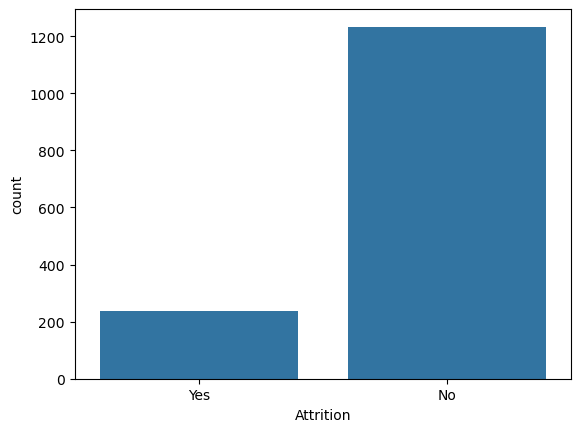

In [4]:

sns.countplot(x='Attrition', data=df)
plt.show()

In [5]:

df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis="columns", inplace=True)

In [6]:

df.shape

(1470, 31)

In [7]:
# Select categorical columns with <= 50 unique values (excluding the target if needed)\

categorical_col = [col for col in df.select_dtypes(include='object').columns if df[col].nunique() <= 50]

print(categorical_col)

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']



df.select_dtypes(include='object')

    → Selects all columns with type object (usually categorical text columns).

if df[col].nunique() <= 50

    → Keeps only those categorical columns that have 50 or fewer unique values.

Why this logic?

Some columns that look categorical might actually have too many unique values.

Example:

    employee_id (1000 unique IDs)
    
    email (1000 unique emails)
    
    address (nearly all unique)

These are not useful categorical features — 

if we use one-hot encode them, we will end up with hundreds/thousands of dummy columns 

    → explosion in dataset size, overfitting, slow training.

By restricting to <= 50 unique values, we keep only "real categorical" features like:

    Gender (M/F)

    Department (HR, IT, Finance, etc.)

    Education level (High school, Graduate, etc.)

🔹 Is it necessary?

    Not strictly necessary — it’s more of a practical safeguard.

    Without it, you might include columns that shouldn’t be encoded, leading to:

        Very large feature space.

        Memory issues.

        Slower training.

        Overfitting.

In [8]:
# Convert 'Attrition' from 'Yes'/'No' to 1/0

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [9]:

df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [10]:

categorical_col.remove('Attrition')

In [11]:

print(categorical_col)

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [12]:

from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
for column in categorical_col:
    df[column] = label.fit_transform(df[column])

In [13]:

print(categorical_col)

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [14]:

from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df.Attrition


In [15]:

X

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,1102,2,1,2,1,2,0,94,...,3,1,0,8,0,1,6,4,0,5
1,49,1,279,1,8,1,1,3,1,61,...,4,4,1,10,3,3,10,7,1,7
2,37,2,1373,1,2,2,4,4,1,92,...,3,2,0,7,3,3,0,0,0,0
3,33,1,1392,1,3,4,1,4,0,56,...,3,3,0,8,3,3,8,7,3,0
4,27,2,591,1,2,1,3,1,1,40,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,1,884,1,23,2,3,3,1,41,...,3,3,1,17,3,3,5,2,0,3
1466,39,2,613,1,6,1,3,4,1,42,...,3,1,1,9,5,3,7,7,1,7
1467,27,2,155,1,4,3,1,2,1,87,...,4,2,1,6,0,3,6,2,0,3
1468,49,1,1023,2,2,3,3,4,1,63,...,3,4,0,17,3,2,9,6,0,8


In [16]:

y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [17]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### Build a model using function and test with train data and test data

In [18]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def print_score(clf, X_train, y_train, X_test, y_test, train=True):
    if train:
        pred = clf.predict(X_train)
        clf_report = pd.DataFrame(classification_report(y_train, pred, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(y_train, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, pred)}\n")
        
    elif train==False:
        pred = clf.predict(X_test)
        clf_report = pd.DataFrame(classification_report(y_test, pred, output_dict=True))
        print("Test Result:\n================================================")        
        print(f"Accuracy Score: {accuracy_score(y_test, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_test, pred)}\n")
        

#### DT

In [19]:

from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')
tree_clf.fit(X_train, y_train)

print_score(tree_clf, X_train, y_train, X_test, y_test, train=True)
print_score(tree_clf, X_train, y_train, X_test, y_test, train=False)


Train Result:
Accuracy Score: 100.00%
_______________________________________________
CLASSIFICATION REPORT:
               0      1  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    853.0  176.0       1.0     1029.0        1029.0
_______________________________________________
Confusion Matrix: 
 [[853   0]
 [  0 176]]

Test Result:
Accuracy Score: 78.00%
_______________________________________________
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.885559   0.256757  0.780045    0.571158      0.798581
recall       0.855263   0.311475  0.780045    0.583369      0.780045
f1-score     0.870147   0.281481  0.780045    0.575814      0.788722
support    380.000000  61.000000  0.780045  441.000000    441.000000
_______________________________________________
Conf

#### DT with  Hyperparameter tuning

In [20]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

params = {
    "criterion":("gini", "entropy"), 
    "splitter":("best", "random"), 
    "max_depth":(list(range(1, 20))), 
    "min_samples_split":[2, 3, 4], 
    "min_samples_leaf":list(range(1, 20)), 
}


tree_clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')
tree_cv = GridSearchCV(
    tree_clf, 
    params, 
    scoring="f1", 
    n_jobs=-1, 
    verbose=1, 
    cv=3
)

tree_cv.fit(X_train, y_train)
best_params = tree_cv.best_params_
print(f"Best paramters: {best_params})")

tree_clf = DecisionTreeClassifier(**best_params)
tree_clf.fit(X_train, y_train)
print_score(tree_clf, X_train, y_train, X_test, y_test, train=True)
print_score(tree_clf, X_train, y_train, X_test, y_test, train=False)


Fitting 3 folds for each of 4332 candidates, totalling 12996 fits
Best paramters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 6, 'min_samples_split': 2, 'splitter': 'best'})
Train Result:
Accuracy Score: 85.91%
_______________________________________________
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.863450    0.781818  0.859086     0.822634      0.849487
recall       0.985932    0.244318  0.859086     0.615125      0.859086
f1-score     0.920635    0.372294  0.859086     0.646465      0.826847
support    853.000000  176.000000  0.859086  1029.000000   1029.000000
_______________________________________________
Confusion Matrix: 
 [[841  12]
 [133  43]]

Test Result:
Accuracy Score: 86.85%
_______________________________________________
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.876168   0.615385  0.868481    0.745776      0.840096
recall      

#### RF

In [22]:

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced')
rf_clf.fit(X_train, y_train)

print_score(rf_clf, X_train, y_train, X_test, y_test, train=True)
print_score(rf_clf, X_train, y_train, X_test, y_test, train=False)


Train Result:
Accuracy Score: 100.00%
_______________________________________________
CLASSIFICATION REPORT:
               0      1  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    853.0  176.0       1.0     1029.0        1029.0
_______________________________________________
Confusion Matrix: 
 [[853   0]
 [  0 176]]

Test Result:
Accuracy Score: 86.62%
_______________________________________________
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.870670   0.625000  0.866213    0.747835      0.836688
recall       0.992105   0.081967  0.866213    0.537036      0.866213
f1-score     0.927429   0.144928  0.866213    0.536178      0.819192
support    380.000000  61.000000  0.866213  441.000000    441.000000
_______________________________________________
Conf

#### Random Forest hyperparameter tuning

### a) Randomized Search Cross Validation

In [23]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

n_estimators = [int(x) for x in np.linspace(start=100, stop=1000, num=10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 110, num=11)]
max_depth.append(None)
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
bootstrap = [True, False]

random_grid = {
    'n_estimators': n_estimators, 
    'max_features': max_features,
    'max_depth': max_depth, 
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf, 
    'bootstrap': bootstrap
}

rf_clf = RandomForestClassifier(random_state=42,class_weight='balanced')

rf_cv = RandomizedSearchCV(
    estimator=rf_clf, 
    param_distributions=random_grid, 
    n_iter=50, 
    cv=3, 
    verbose=1, 
    random_state=42, 
    n_jobs=-1,
    scoring='f1'  # Use appropriate scoring based on your problem
)

rf_cv.fit(X_train, y_train)

rf_best_params = rf_cv.best_params_
print(f"Best parameters: {rf_best_params}")

rf_clf = RandomForestClassifier(**rf_best_params, random_state=42)
rf_clf.fit(X_train, y_train)

print_score(rf_clf, X_train, y_train, X_test, y_test, train=True)
print_score(rf_clf, X_train, y_train, X_test, y_test, train=False)


Fitting 3 folds for each of 50 candidates, totalling 150 fits


C:\Users\nvgra\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
48 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
23 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\nvgra\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\nvgra\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\nvgra\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\nvgra\anaconda3\Lib\site-packages

Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 80, 'bootstrap': False}
Train Result:
Accuracy Score: 96.11%
_______________________________________________
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.955207    1.000000  0.961127     0.977604      0.962869
recall       1.000000    0.772727  0.961127     0.886364      0.961127
f1-score     0.977090    0.871795  0.961127     0.924443      0.959081
support    853.000000  176.000000  0.961127  1029.000000   1029.000000
_______________________________________________
Confusion Matrix: 
 [[853   0]
 [ 40 136]]

Test Result:
Accuracy Score: 86.17%
_______________________________________________
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.870070   0.500000  0.861678    0.685035      0.818881
recall       0.986842   0.081967  0.861678    0.5344

### b) Grid Search Cross Validation

In [ ]:

n_estimators = [100, 500, 1000]
max_features = ['auto', 'sqrt']
max_depth = [2, 3, 5]
max_depth.append(None)
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4, 10]
bootstrap = [True, False]

params_grid = {
    'n_estimators': n_estimators, 
    'max_features': max_features,
    'max_depth': max_depth, 
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf, 
    'bootstrap': bootstrap
}

rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_cv = GridSearchCV(
    rf_clf, 
    params_grid, 
    scoring="f1", 
    cv=3, 
    verbose=1, 
    n_jobs=-1
)

rf_cv.fit(X_train, y_train)
best_params = rf_cv.best_params_
print(f"Best parameters: {best_params}")

rf_clf = RandomForestClassifier(**best_params)
rf_clf.fit(X_train, y_train)

print_score(rf_clf, X_train, y_train, X_test, y_test, train=True)
print_score(rf_clf, X_train, y_train, X_test, y_test, train=False)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits


That message:

"Fitting 5 folds for each of 200 candidates, totalling 1000 fits"

comes from RandomizedSearchCV (or GridSearchCV) in Scikit-learn.


200 candidates: We are testing 200 different combinations of hyperparameters (from param_distributions).

5 folds: For each combination, you're doing 5-fold cross-validation.

This can be computationally expensive, especially for large datasets or complex models like RandomForestClassifier.

If your computer seems slow or CPU usage is high — this is expected.

The n_jobs=-1 option means it's using all available CPU cores to speed things up.